### XGBoost Model

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

################### Load Data #####################################
df = pd.read_csv('2023ActualForecastData.csv')
df1 = pd.read_csv('2024ActualForecastData.csv')
df2 = pd.read_csv('2025ActualForecastData.csv')
AIL = pd.concat([df, df1, df2])
AIL = AIL.dropna(subset=['Hour', 'Date']).reset_index(drop=True) # Removes the extra hour from daylight savings time in November of each year

# Daylight saving time is ignored and the data set is left as is
AIL['Date'] = pd.to_datetime(AIL['Date']) + pd.to_timedelta(AIL['Hour'], unit='h')
print(AIL.head())
print(AIL.tail())


                 Date  Hour  Forecast Pool Price  Actual Posted Pool Price  \
0 2023-01-01 01:00:00   1.0                88.39                     80.55   
1 2023-01-01 02:00:00   2.0               102.36                     80.84   
2 2023-01-01 03:00:00   3.0                80.82                     80.63   
3 2023-01-01 04:00:00   4.0                80.61                     79.76   
4 2023-01-01 05:00:00   5.0                77.88                     79.53   

   Forecast AIL  Actual AIL  Forecast AIL & Actual AIL Difference  
0          9832        9824                                     8  
1          9723        9712                                    11  
2          9634        9623                                    11  
3          9578        9578                                     0  
4          9541        9599                                   -58  
                     Date  Hour  Forecast Pool Price  \
26296 2025-12-31 20:00:00  20.0                19.92   
26297 2025-

### Create Model Features

In [19]:
def create_features(data):
    """
    :param data: Series with DatetimeIndex
    :return: DataFrame
    """
    data = data.copy()  # ← avoid modifying original DataFrame

    # Time features
    data['Hour'] = data['Date'].dt.hour
    data['Day'] = data['Date'].dt.dayofweek
    data['Month'] = data['Date'].dt.month
    data['is_weekend'] = (data['Date'].dt.dayofweek >= 5).astype(int)

    # Lagged features, how much the previous day affects the current day ie. Autoregression
    data['lag1'] = data['Actual AIL'].shift(1) # 1 hour ago
    data['lag24'] = data['Actual AIL'].shift(24) # 24 hours ago
    data['lag168'] = data['Actual AIL'].shift(168) # Same day last week

    # Moving Average
    # Shift 1 as to not include current value
    data['MA3'] = data['Actual AIL'].shift(1).rolling(3).mean() # 3-hour average
    data['MA24'] = data['Actual AIL'].shift(1).rolling(24).mean() # 24-hour average
    data['MA168'] = data['Actual AIL'].shift(1).rolling(168).mean() # Weekly average

    data = data.dropna()

    feature_cols = ['Hour', 'Day', 'Month', 'is_weekend',
                'lag1', 'lag24', 'lag168', 'MA3', 'MA24', 'MA168']
    X = data[feature_cols]  # Features used to predict
    Y = data['Actual AIL']  # Target what is getting predicted

    return X, Y

### Walk Forward Validation

Walk forward validation iteratively trains and tests a model on a consistent window size consecutive periods.Think of it like a sliding window. The model is updated on every training set allowing the model to capture patterns and detect drifts.

#### Walk Forward Validation: Deriving Window Size
##### Problem

Given a dataset of length `len(DF)`, a desired number of folds `n_folds`, and a training spilt ratio `r`, find:
- `x` — the step size
- `y` — the fold length (training window + test window)

---

#### Two Equations, Two Unknowns

##### Equation 1 — Rolling Window Formula

Each fold advances by one step `x`, and the first fold requires a full fold length `y`:

$$\text{len(DF)} = y + ( \text{nfolds} - 1) \cdot x$$

##### Equation 2 — Train/Test Ratio

Given a training ratio `r`, the fold length `y` is related to the step `x` by:

$$y = \frac{x}{1 - r}$$

---

In [39]:
def walk_forward_validation_performance(DataFrame, n_folds, train_window_ratio, feature_function):
    """
    This function applies a walk forward validation to assess model performance.
    :param: Dataframe, with time
    :param: n_folds, number of folds
    :param: train_window_ratio,
    :param: feature_function,
    :return: Mean_squared_error, Actual_AIL, Predicted_AIL
    """
    actual_AIL = []
    predicted_AIL = []


    total = len(DataFrame)
    fold_length = int(total/(1 + (n_folds - 1)*(1-train_window_ratio)))
    step_size = int(fold_length*(1 - train_window_ratio))
    training_window = fold_length - step_size

    # range(start, stop, step)
    for i in range(
        0, total - fold_length, step_size
    ):
        # Split data into training and testing sets
        train_dataset = DataFrame[i:i + training_window]
        test_dataset = DataFrame[i + training_window: i + training_window + step_size]

        # Prepare features for training and testing
        X_train, Y_train = feature_function(train_dataset)
        X_test, Y_test = feature_function(test_dataset)

        model = xgb.XGBRegressor(
            n_estimators=500,   # Number of trees to build
            learning_rate=0.05, # How much each tree contributes
            max_depth=3,        # How many levels of questions
            random_state=42
        )

        model.fit(X_train, Y_train)
        preds = model.predict(X_test)

        actual_AIL.extend(Y_test)
        predicted_AIL.extend(preds)

    mse = mean_squared_error(actual_AIL, predicted_AIL)
    rmse = mse ** 0.5

    return {
        'mse'           : mse,
        'rmse'          : rmse,
        'actual_AIL'    : actual_AIL,
        'predicted_AIL' : predicted_AIL
    }

### Plot Results

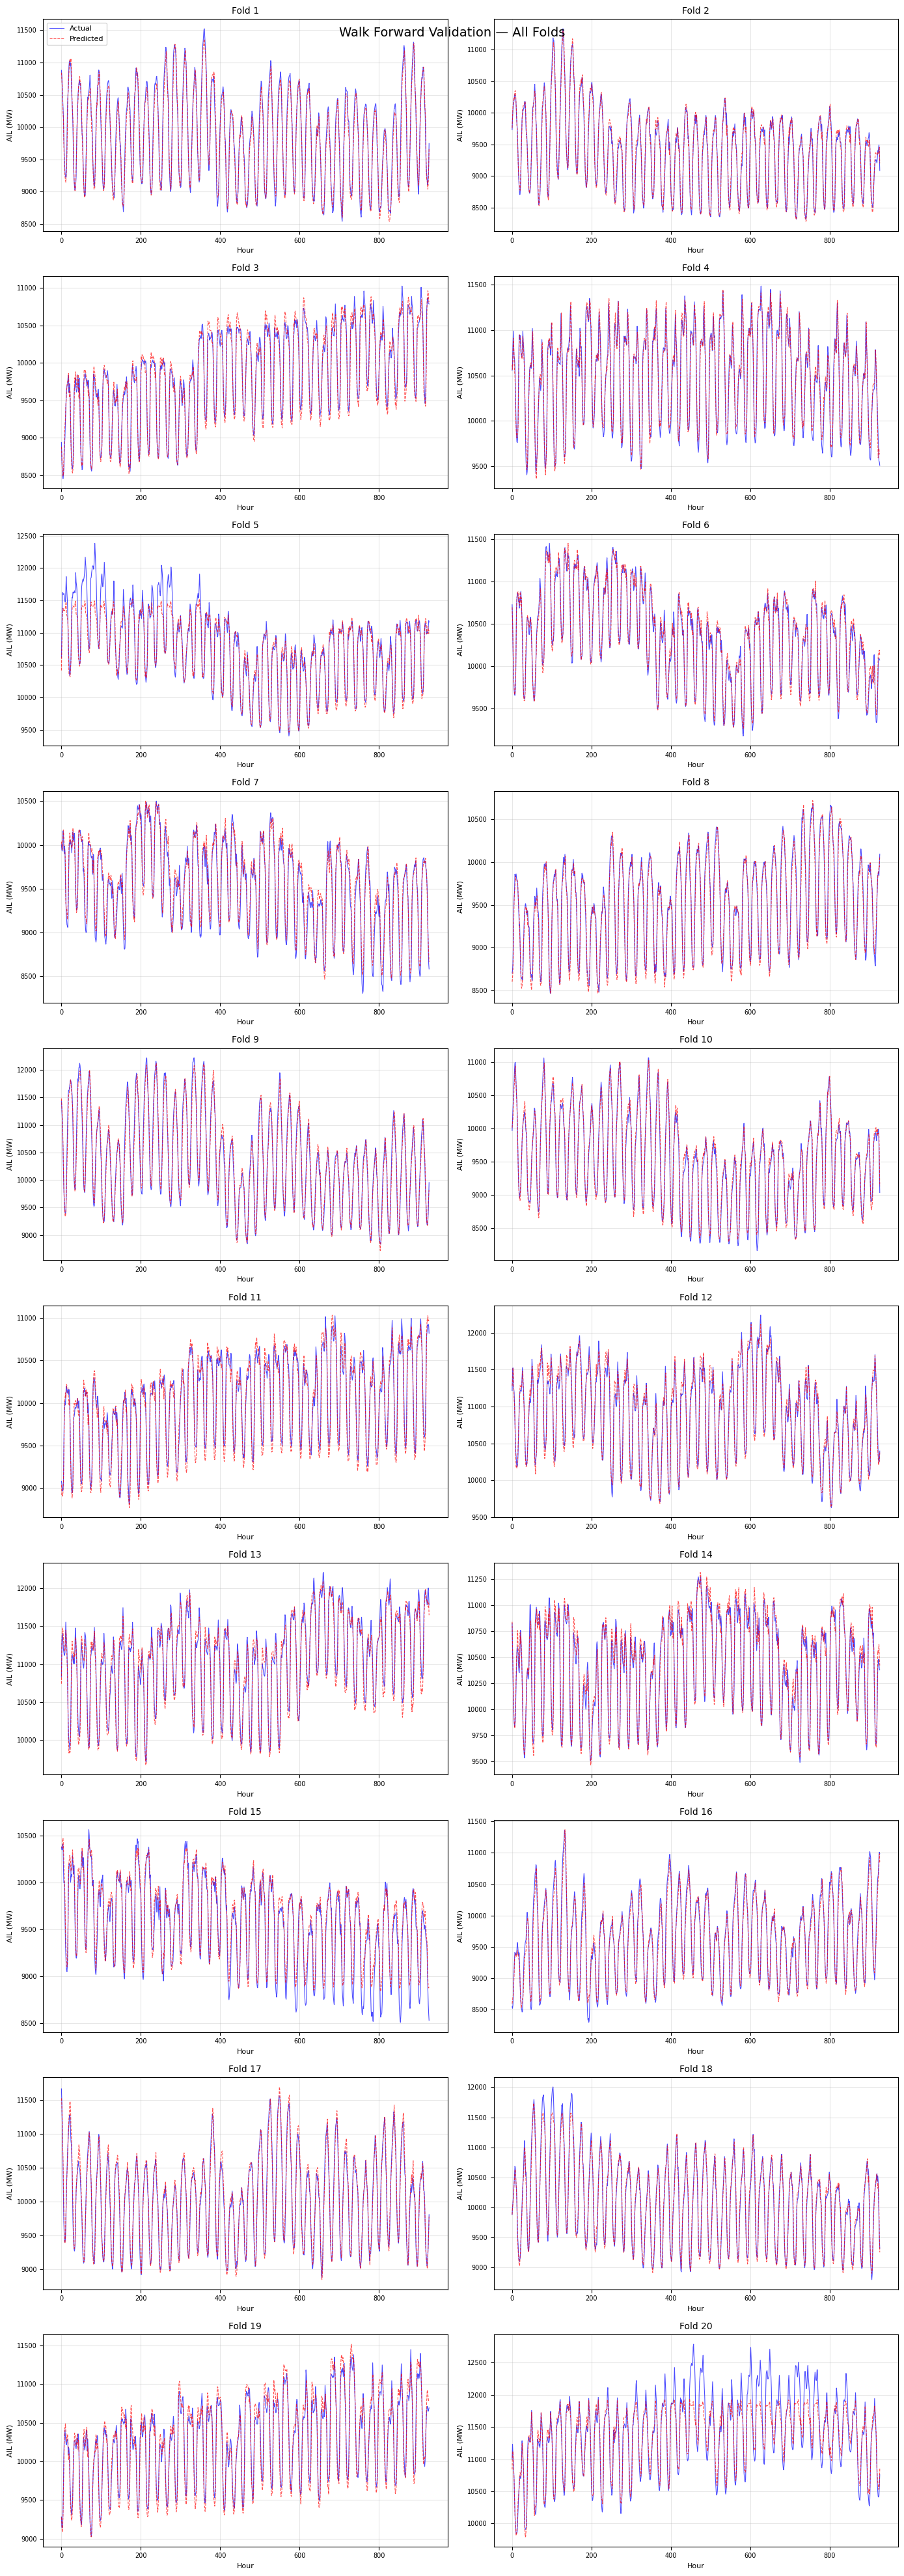

MSE:  12,338 MW
RMSE: 111 MW


In [40]:
# Run the Walk Forward Validation Process
results = walk_forward_validation_performance(
    AIL,
    n_folds=20,
    train_window_ratio=0.8,
    feature_function=create_features
)

Actual_AIL = results['actual_AIL']
Predicted_AIL = results['predicted_AIL']

# Plot the results
total      = len(Actual_AIL)
fold_size  = total // 20

fig, axes = plt.subplots(10, 2, figsize=(14, 40))
axes = axes.flatten()

for i in range(20):
    start = i * fold_size
    end   = start + fold_size

    act  = Actual_AIL[start:end]
    pred = Predicted_AIL[start:end]

    axes[i].plot(act,  'b-',  label='Actual',    alpha=0.7, linewidth=0.8)
    axes[i].plot(pred, 'r--', label='Predicted', alpha=0.7, linewidth=0.8)
    axes[i].set_title(f'Fold {i + 1}', fontsize=10)
    axes[i].set_xlabel('Hour', fontsize=8)
    axes[i].set_ylabel('AIL (MW)', fontsize=8)
    axes[i].tick_params(labelsize=7)
    axes[i].grid(True, alpha=0.3)

    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Walk Forward Validation — All Folds', fontsize=14)
plt.tight_layout()
plt.show()

print(f"MSE:  {results['mse']:,.0f} MW")
print(f"RMSE: {results['rmse']:,.0f} MW")


In [36]:
AIL['Actual AIL'].describe()
print(f"% above 11,700: {(AIL['Actual AIL'] > 11700).mean() * 100:.1f}%")
print(f"% above 12,000: {(AIL['Actual AIL'] > 12000).mean() * 100:.1f}%")

% above 11,700: 2.9%
% above 12,000: 0.9%
